In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp 
from sklearn.linear_model import LinearRegression

### Loading Data

In [15]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

In [16]:
station = df_bike_counts["station"]
bike_count = df_bike_counts["bike_count"]
datetime = pd.to_datetime(df_bike_counts["datetime"])

year, month, day, hour, day_name = datetime.dt.year, datetime.dt.month, datetime.dt.day, datetime.dt.hour, datetime.dt.day_name

### Spliting Data - Langebro Station

In [173]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])

df_merged = pd.merge(df_bike_counts, df_weather, on="datetime")
df_merged.ffill(inplace=True)

df_training = df_merged[(df_merged["datetime"].dt.year == 2021) & (df_merged["station"] == Station)].copy()
df_validating = df_merged[(df_merged["datetime"].dt.year == 2022) & (df_merged["station"] == Station)].copy()
df_testing = df_merged[(df_merged["datetime"].dt.year == 2023) & (df_merged["station"] == Station)].copy()

### Baseline Model - Predicting bike count from hour only

In [182]:
X = np.array(df_training['datetime'].dt.hour).reshape(-1, 1) #input
y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

regr = LinearRegression()
regr.fit(X, y)

R2 = regr.score(X, y)
m = regr.coef_
c = regr.intercept_

def predict_count(h):
    pred = m*h + c
    return pred.flatten()

R2

0.010135418606116553

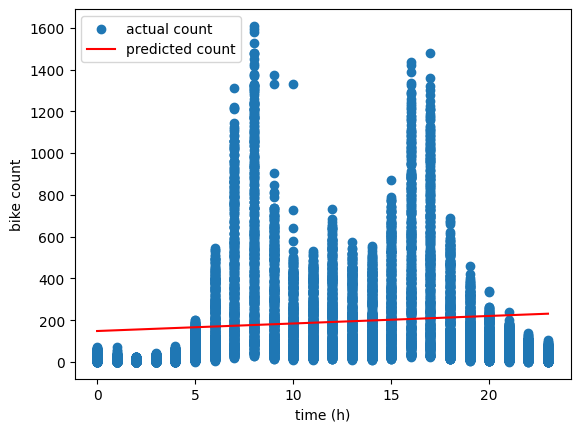

In [191]:
time_eval = np.arange(0, 24, 1)

plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
plt.plot(time_eval, predict_count(time_eval), label="predicted count", color = "red")
plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()

### Improved Model - Predicting bike count from cyclical hour

In [192]:
df_training["h_sin"] = np.sin(2 * np.pi * df_training["datetime"].dt.hour/ 24)
df_training["h_cos"] = np.cos(2 * np.pi * df_training["datetime"].dt.hour/ 24)

X = np.column_stack([df_training["h_sin"], df_training["h_cos"]]) #input
y = np.array(df_training["bike_count"]).reshape(-1, 1) #target

regr = LinearRegression()
regr.fit(X, y)

R2 = regr.score(X, y)

def predict_count_2(h):
    sin_h = np.sin(2 * np.pi * h / 24)
    cos_h = np.cos(2 * np.pi * h / 24)
    X_pred = np.column_stack([sin_h, cos_h])  # works for both scalar and array
    return regr.predict(X_pred).flatten()

R2

0.2119859445083555

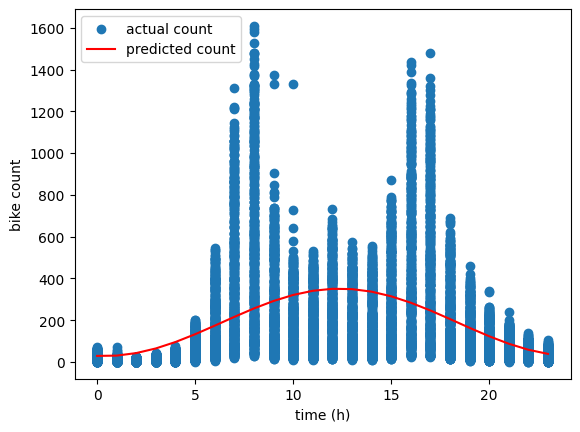

In [193]:
time_eval = np.arange(0, 24, 1)

plt.scatter(df_training["datetime"].dt.hour, df_training["bike_count"], label="actual count")
plt.plot(time_eval, predict_count_2(time_eval), label="predicted count", color = "red")
plt.xlabel("time (h)")
plt.ylabel('bike count')
plt.legend()
plt.show()